In [1]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=NQQH-YYJW 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [8]:
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat 
    "coordinates":
        [
            [
              117.58812764552601,
              4.133326974398287
            ],
            [
              117.75161907303544,
              4.133326974398287
            ],
            [
              117.75161907303544,
              3.971832859595736
            ],
            [
              117.58812764552601,
              3.971832859595736
            ],
            [
              117.58812764552601,
              4.133326974398287
            ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-10-01", "2026-06-01"],
    spatial_extent={
        "west": 117.58812764552601,
        "south": 3.971832859595736,
        "east": 117.75161907303544,
        "north": 4.133326974398287
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [5]:
job = s5post.execute_batch(title="NO2 in Nunukan", outputfile="NO2DiNunukan.nc")

0:00:00 Job 'j-26082816305840dfb06d9ac4e7a7f81e': send 'start'
0:00:03 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:08 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:15 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:23 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:33 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:00:46 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:01:01 Job 'j-26082816305840dfb06d9ac4e7a7f81e': queued (progress 0%)
0:01:21 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:01:45 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:02:15 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:02:53 Job 'j-26082816305840dfb06d9ac4e7a7f81e': running (progress N/A)
0:03:40 Job 'j-26082816305840dfb06d9ac4e7a7f81e': finished (progress 100%)


In [7]:
job = s5post.execute_batch(title="CO in Nunukan", outputfile="CODiNunukan.nc")

0:00:00 Job 'j-26082816452642eb97708cfc27871111': send 'start'
0:00:03 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:09 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:15 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:23 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:33 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:46 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:01:02 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:01:21 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:01:45 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:02:15 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:02:53 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:03:40 Job 'j-26082816452642eb97708cfc27871111': finished (progress 100%)


In [9]:
job = s5post.execute_batch(title="SO2 in Nunukan", outputfile="SO2DiNunukan.nc")

0:00:00 Job 'j-2608281659564944a512b72ca6580a13': send 'start'
0:00:03 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:08 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:15 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:23 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:33 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:46 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:01 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:21 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:45 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:02:15 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:02:53 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:03:40 Job 'j-2608281659564944a512b72ca6580a13': finished (progress 100%)


In [10]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)
# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

        
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2[i]))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)

In [11]:
import pandas as pd
import netCDF4

file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)
# Ambil SO2
so2 = ds.variables["SO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

        
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2[i]))

df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_no2
})

# Simpan ke CSV
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)

In [12]:
import pandas as pd
import netCDF4

file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)
# Ambil CO
co = ds.variables["CO"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

        
new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2[i]))

df = pd.DataFrame({
    "date": new_dates,
    "CO": new_no2
})

# Simpan ke CSV
df.to_csv("CO_Nunukan_timeseries.csv", index=False)

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1398: UserWarning: Warning: converting a masked element to nan.
  return np.asarray(x, float)


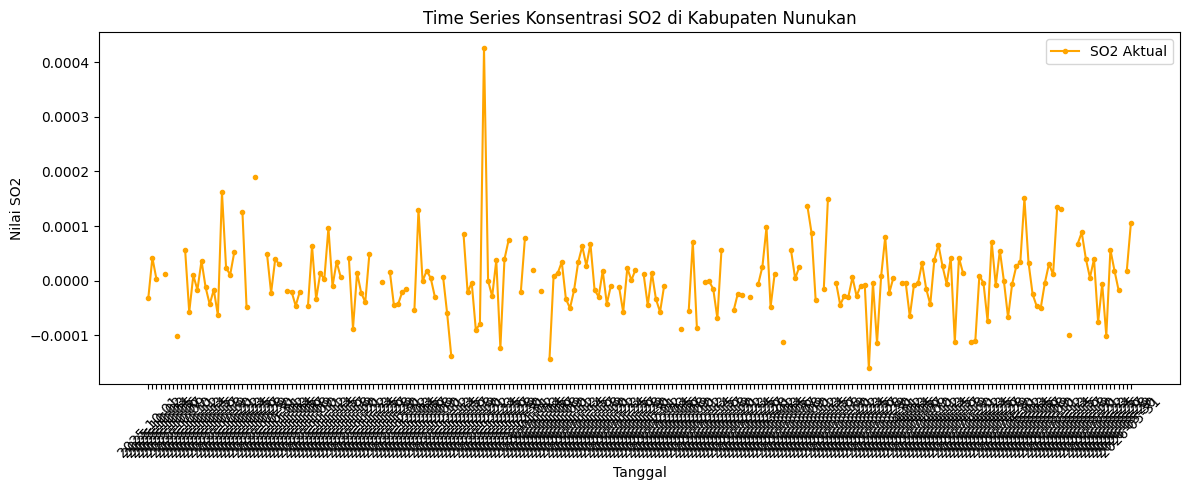

In [1]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil SO2 dan Time
so2 = ds.variables["SO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_so2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_so2.append(np.mean(so2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_so2
})
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai SO2 di sumbu Y
plt.plot(df["date"], df["SO2"], label="SO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi SO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai SO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

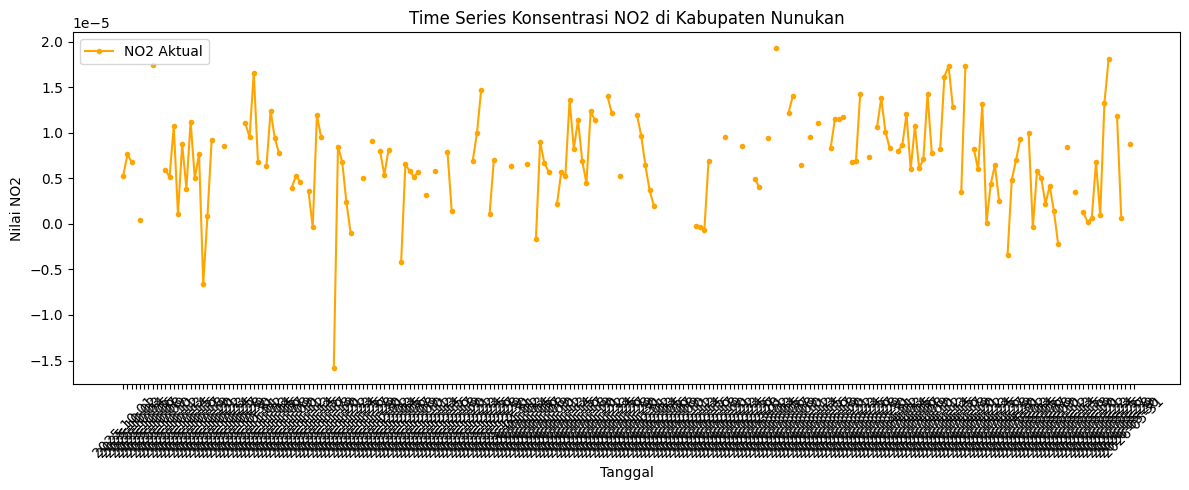

In [3]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil NO2 dan Time
no2 = ds.variables["NO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_no2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_no2.append(np.mean(no2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai NO2 di sumbu Y
plt.plot(df["date"], df["NO2"], label="NO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi NO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai NO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

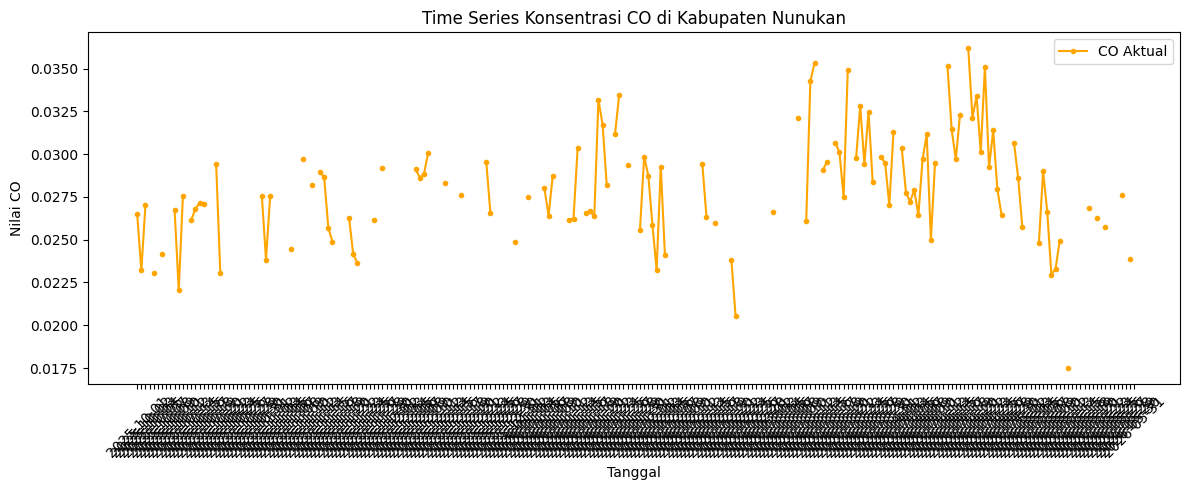

In [5]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil COD dan Time
co = ds.variables["CO"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_co = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_co.append(np.mean(co[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "CO": new_co
})
df.to_csv("CO_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai CO di sumbu Y
plt.plot(df["date"], df["CO"], label="CO Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi CO di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai CO")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()